# FraudGuard — 07: Threshold Tuning

XGBoost modelinin olasılık çıktıları üzerinde karar eşiği analizi. Varsayılan 0.5 ile F1-optimal eşik karşılaştırılır.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import joblib
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

np.random.seed(42)

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
METRICS_DIR   = Path('../results/metrics')
FIGURES_DIR   = Path('../results/figures')

In [2]:
model  = joblib.load(MODELS_DIR / 'xgboost.pkl')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test_scaled.csv')
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f'Test seti: {X_test.shape[0]:,} işlem, {y_test.sum()} fraud')
print(f'Olasılık — min: {y_pred_proba.min():.4f}  max: {y_pred_proba.max():.4f}  ort: {y_pred_proba.mean():.4f}')

Test seti: 56,962 işlem, 98 fraud
Olasılık — min: 0.0000  max: 0.9999  ort: 0.0033


## 1. Olasılık Dağılımı

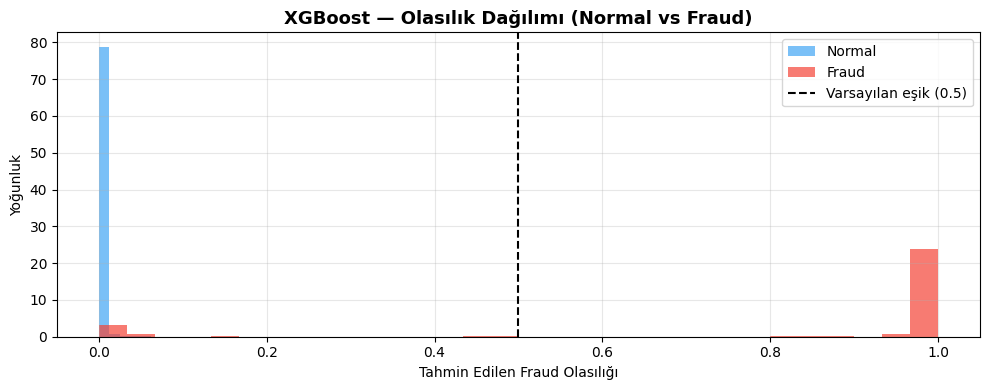

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(y_pred_proba[y_test == 0], bins=80, alpha=0.6, color='#2196F3',
        label='Normal', density=True)
ax.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, color='#F44336',
        label='Fraud', density=True)
ax.axvline(x=0.5, color='k', linestyle='--', lw=1.5, label='Varsayılan eşik (0.5)')
ax.set_xlabel('Tahmin Edilen Fraud Olasılığı')
ax.set_ylabel('Yoğunluk')
ax.set_title('XGBoost — Olasılık Dağılımı (Normal vs Fraud)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Threshold Analizi

In [4]:
thresholds = np.linspace(0.01, 0.99, 200)

precisions, recalls, f1_scores = [], [], []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

precisions = np.array(precisions)
recalls    = np.array(recalls)
f1_scores  = np.array(f1_scores)

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f'Optimal eşik (max F1) : {best_threshold:.4f}')
print(f'Bu eşikte — Precision : {precisions[best_idx]:.4f}')
print(f'Bu eşikte — Recall    : {recalls[best_idx]:.4f}')
print(f'Bu eşikte — F1        : {f1_scores[best_idx]:.4f}')

Optimal eşik (max F1) : 0.9457
Bu eşikte — Precision : 0.9195
Bu eşikte — Recall    : 0.8163
Bu eşikte — F1        : 0.8649


## 3. Eşik–Metrik Eğrisi

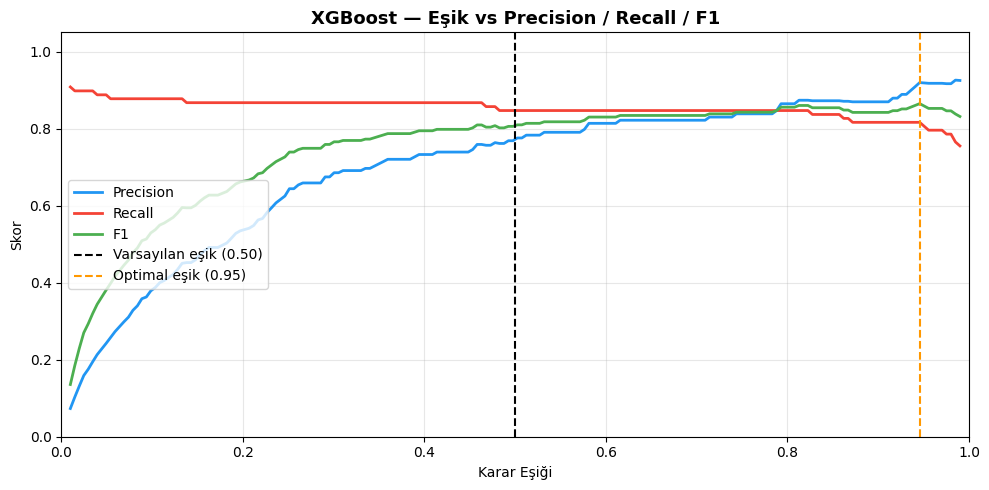

Saved: 17_threshold_metrics_curve.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, precisions, color='#2196F3', lw=2, label='Precision')
ax.plot(thresholds, recalls,    color='#F44336', lw=2, label='Recall')
ax.plot(thresholds, f1_scores,  color='#4CAF50', lw=2, label='F1')
ax.axvline(x=0.5,            color='k',       linestyle='--', lw=1.5, label='Varsayılan eşik (0.50)')
ax.axvline(x=best_threshold, color='#FF9800', linestyle='--', lw=1.5,
           label=f'Optimal eşik ({best_threshold:.2f})')
ax.set_xlabel('Karar Eşiği')
ax.set_ylabel('Skor')
ax.set_title('XGBoost — Eşik vs Precision / Recall / F1', fontsize=13, fontweight='bold')
ax.legend(loc='center left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '17_threshold_metrics_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 17_threshold_metrics_curve.png')

## 4. Karşılaştırma: Varsayılan (0.5) vs Optimal Eşik

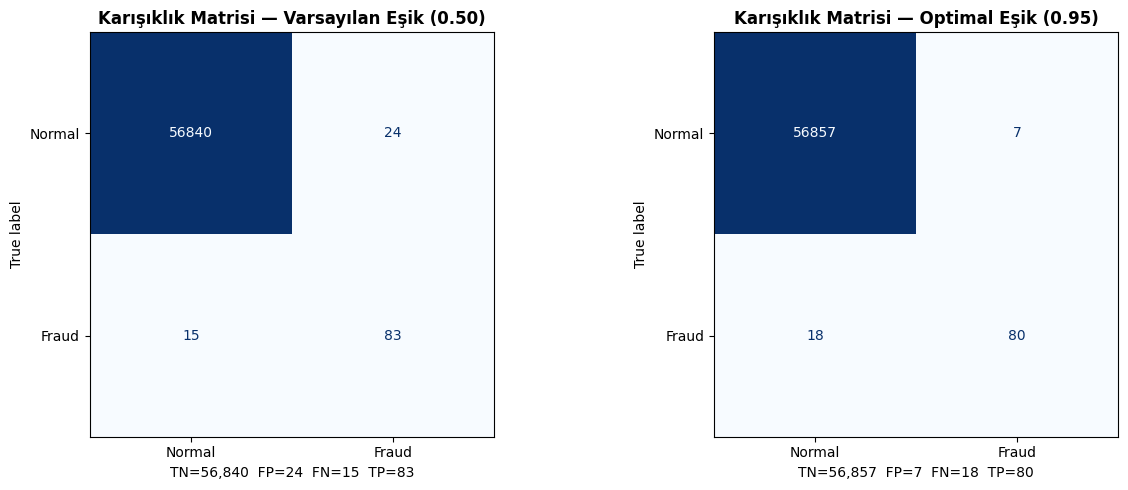

Saved: 18_threshold_confusion_matrix.png

=== Eşik Karşılaştırması ===
        Precision  Recall      F1  TP  FP  FN
Eşik                                         
0.5000     0.7757  0.8469  0.8098  83  24  15
0.9457     0.9195  0.8163  0.8649  80   7  18


In [6]:
y_pred_default = (y_pred_proba >= 0.5).astype(int)
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, title in [
    (axes[0], cm_default, 'Varsayılan Eşik (0.50)'),
    (axes[1], cm_optimal, f'Optimal Eşik ({best_threshold:.2f})'),
]:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Karışıklık Matrisi — {title}', fontsize=12, fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'TN={tn:,}  FP={fp}  FN={fn}  TP={tp}', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '18_threshold_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 18_threshold_confusion_matrix.png')

# Metrik tablosu
comparison = pd.DataFrame([
    {
        'Eşik'     : 0.50,
        'Precision': round(precision_score(y_test, y_pred_default), 4),
        'Recall'   : round(recall_score(y_test, y_pred_default), 4),
        'F1'       : round(f1_score(y_test, y_pred_default), 4),
        'TP'       : int(cm_default.ravel()[3]),
        'FP'       : int(cm_default.ravel()[1]),
        'FN'       : int(cm_default.ravel()[2]),
    },
    {
        'Eşik'     : round(float(best_threshold), 4),
        'Precision': round(float(precisions[best_idx]), 4),
        'Recall'   : round(float(recalls[best_idx]), 4),
        'F1'       : round(float(f1_scores[best_idx]), 4),
        'TP'       : int(cm_optimal.ravel()[3]),
        'FP'       : int(cm_optimal.ravel()[1]),
        'FN'       : int(cm_optimal.ravel()[2]),
    },
]).set_index('Eşik')

print('\n=== Eşik Karşılaştırması ===')
print(comparison.to_string())

## 5. Sonuç Kaydet

In [7]:
tn_d, fp_d, fn_d, tp_d = cm_default.ravel()
tn_o, fp_o, fn_o, tp_o = cm_optimal.ravel()

results = {
    'model'           : 'XGBClassifier',
    'step'            : '09_threshold_tuning',
    'default_threshold': {
        'threshold': 0.5,
        'precision': round(float(precision_score(y_test, y_pred_default)), 4),
        'recall'   : round(float(recall_score(y_test, y_pred_default)), 4),
        'f1'       : round(float(f1_score(y_test, y_pred_default)), 4),
        'confusion_matrix': {'TN': int(tn_d), 'FP': int(fp_d), 'FN': int(fn_d), 'TP': int(tp_d)}
    },
    'optimal_threshold': {
        'threshold': round(float(best_threshold), 4),
        'precision': round(float(precisions[best_idx]), 4),
        'recall'   : round(float(recalls[best_idx]), 4),
        'f1'       : round(float(f1_scores[best_idx]), 4),
        'confusion_matrix': {'TN': int(tn_o), 'FP': int(fp_o), 'FN': int(fn_o), 'TP': int(tp_o)}
    }
}

with open(METRICS_DIR / '09_threshold_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
print('\nSaved: 09_threshold_metrics.json')

{
  "model": "XGBClassifier",
  "step": "09_threshold_tuning",
  "default_threshold": {
    "threshold": 0.5,
    "precision": 0.7757,
    "recall": 0.8469,
    "f1": 0.8098,
    "confusion_matrix": {
      "TN": 56840,
      "FP": 24,
      "FN": 15,
      "TP": 83
    }
  },
  "optimal_threshold": {
    "threshold": 0.9457,
    "precision": 0.9195,
    "recall": 0.8163,
    "f1": 0.8649,
    "confusion_matrix": {
      "TN": 56857,
      "FP": 7,
      "FN": 18,
      "TP": 80
    }
  }
}

Saved: 09_threshold_metrics.json
